In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

### 1. Carga e inspección inicial

In [6]:
DATA_PATH = Path("../data/raw/sesiones_surf.csv")

df = pd.read_csv(DATA_PATH)

df.head()


,id_sesion,fecha,spot,altura_ola_m,periodo_s,direccion_swell,viento_kmh,direccion_viento,marea,temp_agua,num_surfistas,valoracion,buena_sesion
0,S100806,2023-11-23,SOMO,1.18,16.9,273,13.1,NW,baja,18.5,33,4,No
1,S100875,2023-06-18,Somo,1.79,5.3,317,9.5,NaN,media,16.6,27,4,No
2,S100206,2024-05-28,Pantin,1.70,12.8,332,28.8,S,baja,18.2,19,4,Yes
3,S101506,2023-01-21,Rodiles,1.78,9.0,326,13.9,N,alta,15.2,25,3,No
4,S101520,2023-01-15,Rodiles,0.57,7.7,354,17.3,N,baja,21.5,15,3,No


In [9]:
df.shape

(2012, 13)

El data frame contiene  2012 filas y 13 columnas. La variable objetivo es buena_sesion e indica si la sesión ha sido buena o mala. 

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2012 entries, 0 to 2011
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_sesion         2012 non-null   str    
 1   fecha             2012 non-null   str    
 2   spot              2012 non-null   str    
 3   altura_ola_m      2012 non-null   float64
 4   periodo_s         2012 non-null   float64
 5   direccion_swell   2012 non-null   int64  
 6   viento_kmh        1911 non-null   float64
 7   direccion_viento  1932 non-null   str    
 8   marea             2012 non-null   str    
 9   temp_agua         2012 non-null   str    
 10  num_surfistas     2012 non-null   int64  
 11  valoracion        2012 non-null   int64  
 12  buena_sesion      2012 non-null   str    
dtypes: float64(3), int64(3), str(7)
memory usage: 204.5 KB


Las variables `viento_kmh` y `dirección_viento` contienen datos nulos. La variable fecha esta guardada como `str` y deberia de estar como `datetime`. La cariable `temp_agua` también está guardada como `str` y debería de ser numérica. 

Miramos los valores faltantes:

In [10]:
df.isna().sum().sort_values(ascending=False)

viento_kmh          101
direccion_viento     80
spot                  0
fecha                 0
id_sesion             0
periodo_s             0
altura_ola_m          0
direccion_swell       0
marea                 0
temp_agua             0
num_surfistas         0
valoracion            0
buena_sesion          0
dtype: int64

In [12]:
df.replace(" ", np.nan).isna().sum().sort_values(ascending=False)

viento_kmh          101
direccion_viento     80
temp_agua            60
fecha                 0
id_sesion             0
periodo_s             0
altura_ola_m          0
spot                  0
direccion_swell       0
marea                 0
num_surfistas         0
valoracion            0
buena_sesion          0
dtype: int64

La temperatura tiene espacios en blanco. 

In [13]:
df.duplicated().sum()


np.int64(12)

Hay 12 valores duplicados. 

### 2. Inspección de la variable objetivo. 

La variable objetivo es `buena_sesion`, la cual indica si la sesión se surf ha sido buena (`Yes`) o mala (`No`). Al ser un problema de clasificación binaria, es importante comprobar que las clases estan balanceadas.

In [14]:
df["buena_sesion"].value_counts()

buena_sesion
No     1450
Yes     562
Name: count, dtype: int64

Podemos ver que en un principio hay muchos más valores de que ha sido una mala sesión que una buena. 

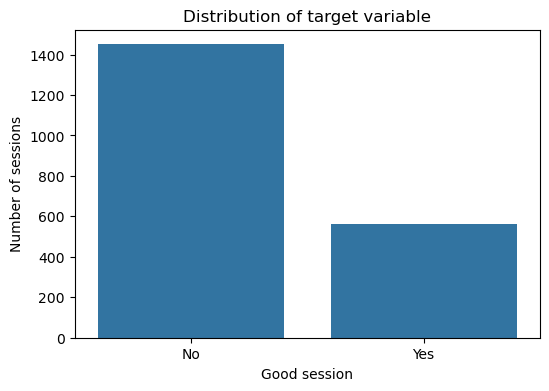

In [15]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="buena_sesion")

plt.title("Distribution of target variable")
plt.xlabel("Good session")
plt.ylabel("Number of sessions")

plt.show()

### 3. Detección de outliers

Miramos si las variables numéricas tienen valores que no son realistas por que podrían ser un error o afectar al entrenamiento del modelo. 

In [17]:
numeric_cols = [
    "altura_ola_m",
    "periodo_s",
    "direccion_swell",
    "viento_kmh",
    "num_surfistas",
    "valoracion"
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
altura_ola_m,2012.0,1.711571,6.207850,0.2,0.69,1.13,1.77,99.0
periodo_s,2012.0,9.973111,3.028648,3.0,8.00,10.00,12.00,20.0
direccion_swell,2012.0,305.699304,31.851042,250.0,278.00,306.00,334.00,360.0
viento_kmh,1911.0,16.082679,11.316142,0.1,7.90,13.40,21.20,60.0
num_surfistas,2012.0,22.744036,5.415743,4.0,19.00,22.00,26.00,46.0
valoracion,2012.0,3.677932,0.633595,1.0,3.00,4.00,4.00,5.0


Como `temp_agua` esta como texto, la transformamos temporalmente para la EDA a númerico para poder mirar su distribución. Para ello hacemos una copía del data frame. 

In [18]:
df_eda = df.copy()

df_eda["temp_agua"] = pd.to_numeric(df_eda["temp_agua"], errors="coerce")

In [19]:
numeric_cols_eda = numeric_cols + ["temp_agua"]

df_eda[numeric_cols_eda].describe().T

,count,mean,std,min,25%,50%,75%,max
altura_ola_m,2012.0,1.711571,6.207850,0.2,0.69,1.13,1.77,99.0
periodo_s,2012.0,9.973111,3.028648,3.0,8.00,10.00,12.00,20.0
direccion_swell,2012.0,305.699304,31.851042,250.0,278.00,306.00,334.00,360.0
viento_kmh,1911.0,16.082679,11.316142,0.1,7.90,13.40,21.20,60.0
num_surfistas,2012.0,22.744036,5.415743,4.0,19.00,22.00,26.00,46.0
valoracion,2012.0,3.677932,0.633595,1.0,3.00,4.00,4.00,5.0
temp_agua,1952.0,17.163525,2.538669,11.0,15.40,17.10,18.90,23.0


In [22]:
anomaly_checks = {
    "altura_ola_m": (0, 10),
}

for col, (lower, upper) in anomaly_checks.items():
    mask = (df_eda[col] < lower) | (df_eda[col] > upper)
    print(f"{col}: {mask.sum()} anomalous values")

altura_ola_m: 8 anomalous values


In [23]:
df_eda[df_eda["altura_ola_m"] > 10]

,id_sesion,fecha,spot,altura_ola_m,periodo_s,direccion_swell,viento_kmh,direccion_viento,marea,temp_agua,num_surfistas,valoracion,buena_sesion
748,S101833,2023-12-11,Mundaka,99.0,10.0,288,11.7,NW,media,16.1,21,4,No
804,S101330,2023-04-14,Sopela,99.0,8.5,323,25.1,S,baja,14.4,18,4,No
962,S100171,2023-06-12,Mundaka,99.0,13.1,336,0.9,SE,media,18.8,29,4,Yes
1156,S100159,2023-04-29,Pantin,99.0,16.4,257,22.9,N,media,15.3,26,4,Yes
1402,S101453,2025-01-13,Zarautz,99.0,8.0,312,19.2,N,alta,17.0,28,4,No
1495,S101197,2025-01-04,Rodiles,99.0,11.4,342,4.6,NW,alta,18.9,27,4,No
1587,S100805,2023-12-16,Pantin,99.0,5.5,273,10.0,E,baja,12.4,19,2,No
1608,S100227,2024-04-13,Somo,99.0,11.4,257,13.0,NW,media,23.0,20,4,No


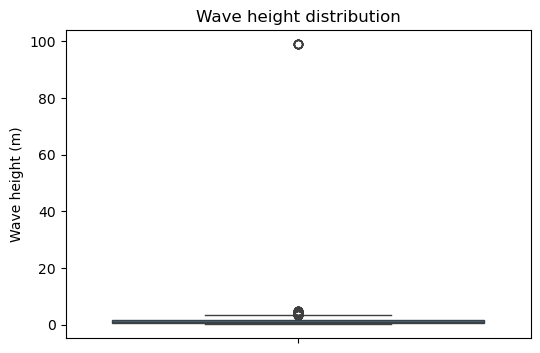

In [24]:
plt.figure(figsize=(6, 4))

sns.boxplot(data=df_eda, y="altura_ola_m")

plt.title("Wave height distribution")
plt.ylabel("Wave height (m)")

plt.show()

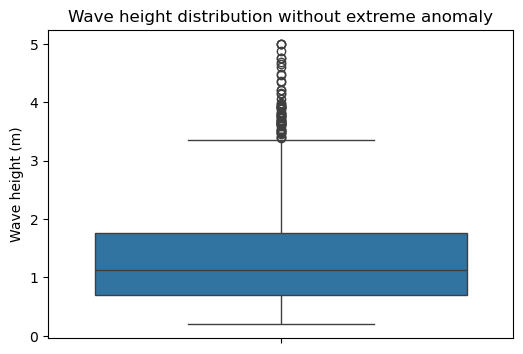

In [25]:
plt.figure(figsize=(6, 4))

sns.boxplot(data=df_eda[df_eda["altura_ola_m"] < 10], y="altura_ola_m")

plt.title("Wave height distribution without extreme anomaly")
plt.ylabel("Wave height (m)")

plt.show()

Claramente, vemos que la variable `altura_ola_m`  8 tiene outliers con el valor de 99 m. Claramente este valor no es realista y no podemos utilizarlo directamente en el modelo. 

El resto de valores númericos entran dentro de un rango normal aunque `temp_agua` tenemos que convertirla de texto a numérico y hay que arreglar los datos faltantes. 

Durante el preprocesado de los datos renplazaremos los outliers de `altura_ola_m` con valores faltantes y será sustituido por un valor estimado. 

### 4. Variables categóricas

A continuación, miramos las variables categoricas ya que inconsistencias en los nombres pueden hacer que tengamos categorías diferentes, cuando en realidad son la misma. 

In [27]:
categorical_cols = ["spot", "direccion_viento", "marea", "buena_sesion"]

for col in categorical_cols:
    print(df[col].value_counts(dropna=False))

spot
Mundaka     274
Rodiles     269
Somo        267
Pantin      257
Zarautz     254
Sopela      246
mundaka      41
Sopela       32
SOMO         31
sopela       29
MUNDAKA      28
RODILES      26
rodiles      26
ZARAUTZ      25
pantin       25
Pantin       24
PANTIN       23
Rodiles      21
SOPELA       21
somo         20
Somo         20
Mundaka      18
zarautz      18
Zarautz      17
Name: count, dtype: int64
direccion_viento
S      363
N      294
SE     273
NW     236
W      213
E      198
NE     184
SW     171
NaN     80
Name: count, dtype: int64
marea
media    674
baja     669
alta     669
Name: count, dtype: int64
buena_sesion
No     1450
Yes     562
Name: count, dtype: int64


Podemos ver muchas inconsistencias en las mayúsculas de los nombres de los spots. 

In [29]:
df["spot"].unique()

<StringArray>
[    'SOMO',     'Somo',   'Pantin',  'Rodiles', 'Rodiles ',  'ZARAUTZ',
  'Zarautz',  'Mundaka',   'Sopela',     'somo', 'Mundaka ',    'Somo ',
   'sopela',   'PANTIN',  'MUNDAKA',  'Pantin ',   'pantin',   'SOPELA',
  'mundaka',  'RODILES',  'zarautz', 'Zarautz ',  'rodiles',  'Sopela ']
Length: 24, dtype: str

Hacemos una copia de la categoría de Spot para la EDA. 

In [33]:
df_eda = df.copy()
df_eda["spot"] = df_eda["spot"].str.strip().str.lower()

print("Number of unique spots before cleaning:")
print(df["spot"].nunique(dropna=False))

print("\nNumber of unique spots after cleaning:")
print(df_eda["spot"].nunique(dropna=False))

df_eda["spot"].value_counts()

Number of unique spots before cleaning:
24

Number of unique spots after cleaning:
6


spot
mundaka    361
rodiles    342
somo       338
pantin     329
sopela     328
zarautz    314
Name: count, dtype: int64

Para evitar crear categorías innecesarias en `spot` en el preprocesado se pasaran todos los nombres a minúsculas y se quitaran todos los espacios en blanco. 

El resto de variables categóricas están bien excepto `direccion_viento` que contiene valores faltantes. 

### 5. Gráficos útiles

En la primra sección hemos visto la distribución de la variable objetivo, la cual está desbalanceada, teniendo más malas sesiones que buenas. 

Vamos a ver un poco que variables están relacionadas con la probabilidad de tener una buena o mala sesión. Teoricamente el periodo tendría que ser una variable importante al igual que el spot. 

In [35]:
df_eda = df.copy()

# Remove duplicates for the exploratory plots
df_eda = df_eda.drop_duplicates()

# Basic cleaning for EDA
df_eda["spot"] = df_eda["spot"].str.strip().str.lower()
df_eda["temp_agua"] = pd.to_numeric(df_eda["temp_agua"], errors="coerce")

# Treat the unrealistic wave height only for visualization
df_eda["altura_ola_m_clean"] = df_eda["altura_ola_m"].mask(df_eda["altura_ola_m"] > 10, np.nan)

# Binary target for aggregation
df_eda["good_session"] = (df_eda["buena_sesion"] == "Yes").astype(int)

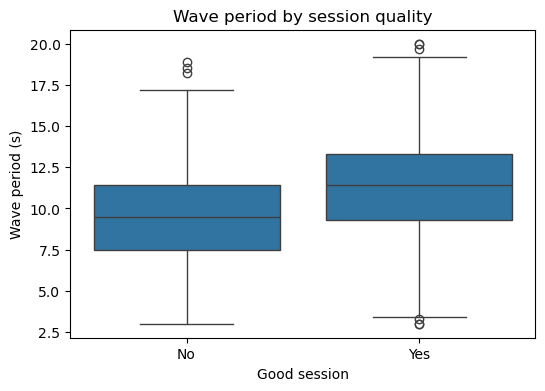

In [37]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_eda,
    x="buena_sesion",
    y="periodo_s"
)

plt.title("Wave period by session quality")
plt.xlabel("Good session")
plt.ylabel("Wave period (s)")

plt.show()

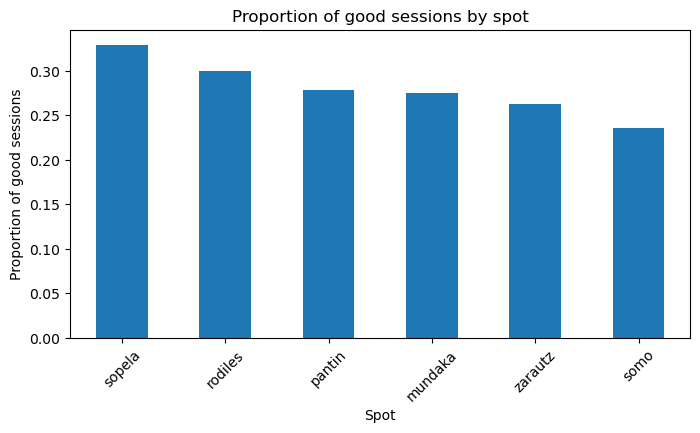

In [38]:
good_by_spot = (
    df_eda
    .groupby("spot")["good_session"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))

good_by_spot.plot(kind="bar")

plt.title("Proportion of good sessions by spot")
plt.xlabel("Spot")
plt.ylabel("Proportion of good sessions")
plt.xticks(rotation=45)

plt.show()

In [39]:
spot_summary = (
    df_eda
    .groupby("spot")
    .agg(
        total_sessions=("buena_sesion", "count"),
        good_sessions=("good_session", "sum"),
        good_session_rate=("good_session", "mean")
    )
    .sort_values("good_session_rate", ascending=False)
)

spot_summary["good_session_rate"] = (spot_summary["good_session_rate"] * 100).round(2)

spot_summary

,total_sessions,good_sessions,good_session_rate
spot,,,
sopela,325,107,32.92
rodiles,340,102,30.00
pantin,327,91,27.83
mundaka,360,99,27.50
zarautz,313,82,26.20
somo,335,79,23.58


Vemos que el periodo en las sesiones malas es más bajo que en las sesiones buenas como carbría esperar. 

El spot no parece determinante a la hora de tener buena o mala sesión pero lo que si que puede influir en ello es la dirección del swell, la dirección del viento o la marea según el spot, ya que no a todos los spots les favorecen las mismas condiciones.  


La id_sesion y el número de surfistas son columnas que no debemos de utilizar para el modelo, ya que uno es un identificador y el otro no lo sabremos hasta después de la sesión. 